In [187]:
import pandas as pd
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [188]:
mlflow.get_tracking_uri()

'http://localhost:5000'

In [189]:
mlflow.set_tracking_uri("http://localhost:5000")      # local MLflow server
mlflow.set_experiment("Baseline model")           # experiment name

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1775973128094, experiment_id='2', last_update_time=1775973128094, lifecycle_stage='active', name='Baseline model', tags={}, workspace='default'>

In [190]:
data = pd.read_csv(r'../data/processed/dataset.csv')

In [191]:
data = data.dropna(subset=['text_processed', 'sentiment'])

In [192]:
data.shape

(10270, 5)

In [193]:
data = data.drop_duplicates()

In [194]:
data.shape

(10241, 5)

##### Split

In [195]:
X_text = data['text_processed']
X_numeric = data[['char_count', 'word_count', 'avg_word_len']].values
y = data['sentiment']


In [196]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

In [197]:
X_text_train.shape

(8192,)

##### feature_representation

In [198]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_text_train = tfidf.fit_transform(X_text_train)
X_text_test  = tfidf.transform(X_text_test)

In [199]:
X_text_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 112645 stored elements and shape (8192, 5000)>

##### Scaling

In [200]:
# Scale numeric — fit on train only
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)  # fit + transform
X_num_test  = scaler.transform(X_num_test)        # only transform

In [201]:
from scipy.sparse import hstack

# Combine TF-IDF + custom features
X_train_final = hstack([X_text_train, X_num_train])
X_test_final  = hstack([X_text_test,  X_num_test])

              precision    recall  f1-score   support

          -1       0.78      0.67      0.72      1029
           0       0.80      0.93      0.86       488
           1       0.51      0.57      0.54       532

    accuracy                           0.71      2049
   macro avg       0.70      0.72      0.71      2049
weighted avg       0.71      0.71      0.71      2049



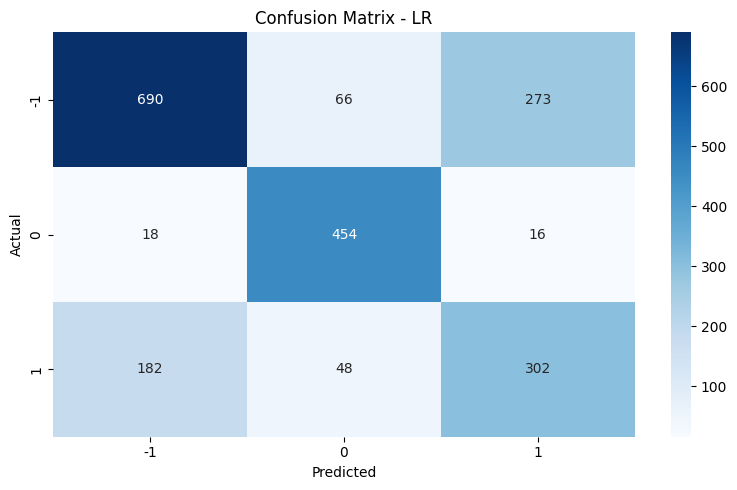

2026/04/12 13:37:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:37:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'sentiment-lr-baseline' already exists. Creating a new version of this model...
2026/04/12 13:37:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sentiment-lr-baseline, version 6


Run ID: 143888bae0bd4f9394d5262103938f8c
🏃 View run baseline-logistic-regression at: http://localhost:5000/#/experiments/2/runs/143888bae0bd4f9394d5262103938f8c
🧪 View experiment at: http://localhost:5000/#/experiments/2


Created version '6' of model 'sentiment-lr-baseline'.


In [202]:
# type: ignore
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)

# ── Run ───────────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name="baseline-logistic-regression"):

    # ── Tags (metadata about the run) ─────────────────────────────────────────
    mlflow.set_tags({
        "author"      : "Rahul Namilakonda",
        "dataset"     : "twitter-reddit-sentiment",
        "model_type"  : "baseline",
        "stage"         : "improved",
        "features"      : "tfidf + char_count + word_count + avg_word_len",                 # baseline / improved / final
    })

    # ── Log Parameters ────────────────────────────────────────────────────────
    mlflow.log_params({
               # Split
        "test_size"             : 0.2,
        "stratify"              : True,
        "random_state"          : 42,

        # TF-IDF
        "tfidf_max_features"    : 5000,
        "tfidf_norm"            : "l2",

        # Scaling
        "scaler"                : "StandardScaler",
        "scaled_features"       : "char_count, word_count, avg_word_len",

        

        # Model
        "model"                 : "LogisticRegression",
        "max_iter"              : 1000,
        "solver"                : "lbfgs",
        "random_state"          : 42,
        "class_weight"          : "balanced",

        # Features
        "num_custom_features"   : 3,
        "tfidf_features"        : 5000,


    })

    # ── Train ─────────────────────────────────────────────────────────────────
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    # ── Log Metrics ───────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "accuracy"         : accuracy_score(y_test, y_pred),
        "f1_weighted"      : f1_score(y_test, y_pred, average='weighted'),
        "f1_macro"         : f1_score(y_test, y_pred, average='macro'),
        "precision_weighted": precision_score(y_test, y_pred, average='weighted'),
        "precision_macro": precision_score(y_test, y_pred, average='macro'),
        "recall_weighted"  : recall_score(y_test, y_pred, average='weighted'),
        "recall_macro"  : recall_score(y_test, y_pred, average='macro'),
    })

    # ── Log Classification Report as artifact ─────────────────────────────────
    report = classification_report(y_test, y_pred)
    print(report)
    with open("../reports/model/classification_report_baseline.txt", "w") as f:
        f.write(report)
    mlflow.log_artifact("../reports/model/classification_report_baseline.txt")

    # ── Log Confusion Matrix as artifact ──────────────────────────────────────
    plt.figure(figsize=(8, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Confusion Matrix - LR')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig("../reports/model/confusion_matrix_baseline.png")
    mlflow.log_artifact("../reports/model/confusion_matrix_baseline.png")
    plt.show()

    # ── Log Model ─────────────────────────────────────────────────────────────
    mlflow.sklearn.log_model(model, artifact_path="model",
                             registered_model_name="sentiment-lr-baseline")

    print(f"Run ID: {mlflow.active_run().info.run_id}")